# <font color='red'>
---
## <center> <font color='red'> Masters in Mathematical Finance
#### <center> <font color='red'> 2024 / 25
# <center> <font color='red'> Programming Techniques
---
# <center> <font color='red'><font> Student: Petr Terletskiy </font>
---
### <center> Algorithmic Finance: Implementing Risk Parity Portfolios and Option Pricing Models
---

### 📋 Project Summary
##### This notebook implements a complete quant workflow:

#### **Part 1: Risk Parity Portfolio**
- User selects the assets he wants for the portfolio
- Optimize weights using risk parity (equal risk contribution)
- Calculate cumulative returns over past year
- Visualize allocations and performance

#### **Part 2: Options Analysis on Top Asset**
- Identify asset with highest allocation
- Calculate Black-Scholes prices for call/put options
- Fetch real market option prices using yfinance
- Compare theoretical vs market prices
- Visualize differences across strikes
---
### **Key Features:**
- Interactive portfolio selection
- Risk-parity optimization with scipy
- Real-time market data fetching
- Black-Scholes implementation from scratch
- Comparative analysis visualization
---
### **Expected Outputs:**
1. Portfolio allocation pie chart
2. Cumulative returns plot (portfolio vs individual assets)
3. Black-Scholes vs market price comparison chart
---

# Risk Parity Portfolio

In [1]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import time

from risk_parity_functions import RiskParityPortfolio
from black_scholes_functions import BlackScholesPricer

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12

import warnings
warnings.filterwarnings('ignore')

print("╔══════════════════════════════════════════════════════════════════════╗")
print("║                RISK PARITY PORTFOLIO BUILDER                         ║")
print("╚══════════════════════════════════════════════════════════════════════╝")
print("\nWelcome! This tool will help you create a personalized risk parity portfolio.")
print("Risk parity equalizes risk contributions from each asset (not capital).")
print("\n" + "═"*70)

╔══════════════════════════════════════════════════════════════════════╗
║                RISK PARITY PORTFOLIO BUILDER                         ║
╚══════════════════════════════════════════════════════════════════════╝

Welcome! This tool will help you create a personalized risk parity portfolio.
Risk parity equalizes risk contributions from each asset (not capital).

══════════════════════════════════════════════════════════════════════


In [2]:
print("\n📚 EXAMPLE ASSETS & TICKERS")
print("═"*70)

# Define the example assets
assets_tickers = {
    "Bitcoin": "BTC-USD", "Ethereum": "ETH-USD", "Solana": "SOL-USD", 
    "Ripple": "XRP-USD", "Chainlink": "LINK-USD", "Litecoin": "LTC-USD", 
    "Dogecoin": "DOGE-USD",   # cryptos
    "Gold": "GLD", "Silver": "SLV", "Copper": "COPX", 
    "Crude Oil": "USO", "Natural Gas": "UNG",  # commodities' ETFs
    "NASDAQ100": "QQQ", "SP500": "SPY", "Dow Jones": "DIA", # index ETFs
    "Apple": "AAPL", "Microsoft": "MSFT", "Meta": "META", 
    "Amazon": "AMZN", "Google": "GOOGL",  # stocks
    "Tesla": "TSLA", "Nvidia": "NVDA", "TSMC": "TSM", 
    "JPMorgan Chase": "JPM", "Coinbase": "COIN"  # stocks
}

# Organize the assets into categories
cryptocurrencies = ["Bitcoin", "Ethereum", "Solana", "Ripple", "Chainlink", "Litecoin", "Dogecoin"]
commodities_etfs = ["Gold", "Silver", "Copper", "Crude Oil", "Natural Gas"]
index_etfs = ["NASDAQ100", "SP500", "Dow Jones"]
stocks = ["Apple", "Microsoft", "Meta", "Amazon", "Google", "Tesla", "Nvidia", "TSMC", "JPMorgan Chase", "Coinbase"]

# Print examples
print("\n💡 Here are some examples of assets and their tickers:")
print("   Use the ticker symbols when prompted (e.g., AAPL, BTC-USD, SPY)")
print("-"*80)

print("\n🔐 Cryptocurrencies:")
for crypto in cryptocurrencies:  
    print(f"   - {crypto:12} → {assets_tickers[crypto]}")

print("\n⛏️  Commodities ETFs:")
for commodity in commodities_etfs:
    print(f"   - {commodity:12} → {assets_tickers[commodity]}")

print("\n📊 Index ETFs:")
for index_etf in index_etfs:
    print(f"   - {index_etf:12} → {assets_tickers[index_etf]}")

print("\n🏢 Company Stocks:")
for stock in stocks:  
    print(f"   - {stock:12} → {assets_tickers[stock]}")

print("\n" + "═"*70)


📚 EXAMPLE ASSETS & TICKERS
══════════════════════════════════════════════════════════════════════

💡 Here are some examples of assets and their tickers:
   Use the ticker symbols when prompted (e.g., AAPL, BTC-USD, SPY)
--------------------------------------------------------------------------------

🔐 Cryptocurrencies:
   - Bitcoin      → BTC-USD
   - Ethereum     → ETH-USD
   - Solana       → SOL-USD
   - Ripple       → XRP-USD
   - Chainlink    → LINK-USD
   - Litecoin     → LTC-USD
   - Dogecoin     → DOGE-USD

⛏️  Commodities ETFs:
   - Gold         → GLD
   - Silver       → SLV
   - Copper       → COPX
   - Crude Oil    → USO
   - Natural Gas  → UNG

📊 Index ETFs:
   - NASDAQ100    → QQQ
   - SP500        → SPY
   - Dow Jones    → DIA

🏢 Company Stocks:
   - Apple        → AAPL
   - Microsoft    → MSFT
   - Meta         → META
   - Amazon       → AMZN
   - Google       → GOOGL
   - Tesla        → TSLA
   - Nvidia       → NVDA
   - TSMC         → TSM
   - JPMorgan Chase → JPM
   

In [3]:
print("\n⚙️ PORTFOLIO CONFIGURATION")
print("="*70)

# Get number of assets
print("\n📊 How many assets would you like in your portfolio?")
while True:
    try:
        num_assets = int(input("Enter number (2-20, recommended 3-8): "))
        if 2 <= num_assets <= 20:
            break
        else:
            print("⚠️  Please enter a number between 2 and 20.")
    except ValueError:
        print("⚠️  Please enter a valid number.")

print(f"\n✅ Great! You'll be selecting {num_assets} assets.")

# Get asset tickers
print("\n🔍 Enter the ticker symbols for your assets:")
print("   Examples: AAPL (Apple), BTC-USD (Bitcoin), SPY (S&P 500), GLD (Gold)")
print("-"*60)

user_tickers = []
for i in range(num_assets):
    while True:
        ticker = input(f"\nAsset {i+1}/{num_assets}: ").strip().upper()
        
        if not ticker:
            print("⚠️  Please enter a ticker symbol.")
            continue
            
        if ticker in user_tickers:
            print(f"⚠️  '{ticker}' is already in your portfolio.")
            continue
        
        # Show confirmation with name if available
        ticker_name = None
        for name, t in assets_tickers.items():
            if t == ticker:
                ticker_name = name
                break
        
        if ticker_name:
            print(f"   Found: {ticker_name}")
        
        confirm = input(f"   Add '{ticker}' to portfolio? (y/n): ").lower().strip()
        if confirm in ['y', 'yes', '']:
            user_tickers.append(ticker)
            print(f"   ✅ Added: {ticker}")
            break
        else:
            print(f"   Skipping {ticker}...")

print("\n" + "="*70)
print(f"🎯 YOUR PORTFOLIO ASSETS ({len(user_tickers)} assets):")
for i, ticker in enumerate(user_tickers):
    name = next((n for n, t in assets_tickers.items() if t == ticker), ticker)
    print(f"{i+1:2}. {name if name != ticker else ticker}")
print("="*70)


⚙️ PORTFOLIO CONFIGURATION

📊 How many assets would you like in your portfolio?

✅ Great! You'll be selecting 3 assets.

🔍 Enter the ticker symbols for your assets:
   Examples: AAPL (Apple), BTC-USD (Bitcoin), SPY (S&P 500), GLD (Gold)
------------------------------------------------------------
   Found: Silver
   ✅ Added: SLV
   Found: TSMC
   ✅ Added: TSM
   Found: Bitcoin
   ✅ Added: BTC-USD

🎯 YOUR PORTFOLIO ASSETS (3 assets):
 1. Silver
 2. TSMC
 3. Bitcoin


In [4]:
print("\n🔄 CREATING YOUR PORTFOLIO")
print("═"*70)

# Get lookback period
print("\n📅 How many years of historical data should we use?")
print("   • 1 year = Focus on recent trends")
print("   • 3 years = Balanced approach (recommended)")
print("   • 5 years = Long-term perspective")

while True:
    try:
        lookback_input = input("\nEnter number of years (1-5, default=3): ").strip()
        if not lookback_input:
            lookback_years = 3
        else:
            lookback_years = float(lookback_input)
        
        if 1 <= lookback_years <= 5:
            break
        else:
            print("⚠️  Please enter a number between 1 and 5.")
    except ValueError:
        print("⚠️  Please enter a valid number.")

print(f"\n✅ Using {lookback_years} years of historical data.")

# Create and fetch portfolio data
print("\n🔄 Creating your portfolio and fetching data...")
portfolio = RiskParityPortfolio(user_tickers, lookback_years=lookback_years)

print("\n⏳ Downloading market data (this may take a moment)...")
print("   (Fetching: " + ", ".join(user_tickers) + ")")

# Simple progress indicator
for i in range(5):
    print("   █" if i % 2 == 0 else "   ░", end="", flush=True)
    time.sleep(0.2)
print()

# Fetch data
success = portfolio.fetch_data()

if not success:
    print("\n❌ ERROR: Could not fetch data for all assets.")
    print("\n   Possible solutions:")
    print("   1. Check your internet connection")
    print("   2. Verify ticker symbols are correct")
    print("   3. Try alternative tickers (e.g., GLD instead of GC=F)")
    print("   4. Some assets may not have sufficient historical data")
    print("   5. Try a shorter lookback period")
    raise SystemExit("Exiting due to data fetch failure.")

print(f"\n✅ Data fetched successfully!")
print(f"   Period: {portfolio.data.index[0].date()} to {portfolio.data.index[-1].date()}")
print(f"   Trading days: {len(portfolio.data):,}")
print(f"   Assets with data: {len(portfolio.data.columns)}")


🔄 CREATING YOUR PORTFOLIO
══════════════════════════════════════════════════════════════════════

📅 How many years of historical data should we use?
   • 1 year = Focus on recent trends
   • 3 years = Balanced approach (recommended)
   • 5 years = Long-term perspective

✅ Using 3.0 years of historical data.

🔄 Creating your portfolio and fetching data...

⏳ Downloading market data (this may take a moment)...
   (Fetching: SLV, TSM, BTC-USD)
   █   ░   █   ░   █
Fetching data from 2023-02-06 to 2026-02-05...
  ✓ SLV: 752 days of data
  ✓ TSM: 752 days of data
  ✓ BTC-USD: 1095 days of data

✅ Successfully fetched 751 days of data for 3 assets

✅ Data fetched successfully!
   Period: 2023-02-06 to 2026-02-03
   Trading days: 751
   Assets with data: 3


In [5]:
if success:
    print("\n" + "═"*70)
    print("⚖️  OPTIMIZING PORTFOLIO WEIGHTS")
    print("═"*70)
    
    print("\nOptimizing risk parity weights...")
    print("(This finds weights that equalize risk contributions from each asset)")
    
    # Simple progress indicator
    for i in range(5):
        print("   █" if i % 2 == 0 else "   ░", end="", flush=True)
        time.sleep(0.3)
    print("\n")
    
    # Optimize weights
    weights = portfolio.optimize_weights()
    
    # Display weights
    print("✅ Optimization complete!")
    print("\n" + "─"*70)
    print("YOUR PORTFOLIO ALLOCATION:")
    print("─"*70)
    
    # Get asset names for display
    display_names = []
    for ticker in portfolio.tickers:
        name = next((n for n, t in assets_tickers.items() if t == ticker), ticker)
        display_names.append(name)
    
    # Sort by weight (highest first)
    weight_data = list(zip(display_names, portfolio.tickers, portfolio.weights, portfolio.risk_contributions))
    weight_data.sort(key=lambda x: x[2], reverse=True)
    
    print("\nRank  Asset              Ticker     Weight   Risk Contribution")
    print("-"*70)
    
    for i, (name, ticker, weight, risk_contrib) in enumerate(weight_data):
        # Create a simple bar for visualization
        bar_length = int(weight * 30)
        bar = "█" * bar_length
        
        print(f"{i+1:2}.   {name:15}   {ticker:8}   {weight:6.1%}   {risk_contrib:5.1%}   {bar}")
    
    print("\n" + "─"*70)
    print("💡 Interpretation:")
    print("   • Weight = % of capital allocated to each asset")
    print("   • Risk Contribution = % of total portfolio risk from each asset")
    print("   • In risk parity, we aim for equal risk contributions")


══════════════════════════════════════════════════════════════════════
⚖️  OPTIMIZING PORTFOLIO WEIGHTS
══════════════════════════════════════════════════════════════════════

Optimizing risk parity weights...
(This finds weights that equalize risk contributions from each asset)
   █   ░   █   ░   █

✅ Optimization complete!

──────────────────────────────────────────────────────────────────────
YOUR PORTFOLIO ALLOCATION:
──────────────────────────────────────────────────────────────────────

Rank  Asset              Ticker     Weight   Risk Contribution
----------------------------------------------------------------------
 1.   Silver            SLV         37.8%   33.3%   ███████████
 2.   TSMC              TSM         34.6%   33.3%   ██████████
 3.   Bitcoin           BTC-USD     27.6%   33.3%   ████████

──────────────────────────────────────────────────────────────────────
💡 Interpretation:
   • Weight = % of capital allocated to each asset
   • Risk Contribution = % of total po

In [6]:
if success:
    print("\n" + "═"*70)
    print("📊 PERFORMANCE SUMMARY")
    print("═"*70)
    
    # Calculate metrics
    metrics = portfolio.calculate_performance_metrics(lookback_days=252)
    top_asset_ticker, top_weight, idx = portfolio.get_top_asset()
    
    # Get the name of the top asset
    top_asset_name = next((n for n, t in assets_tickers.items() if t == top_asset_ticker), top_asset_ticker)
    
    print(f"\n📈 YOUR PORTFOLIO PERFORMANCE (Last Year):")
    print("─"*45)
    print(f"   Total Return:       {metrics['total_return']:>10.2%}")
    print(f"   Annualized Return:  {metrics['annualized_return']:>10.2%}")
    print(f"   Volatility:         {metrics['volatility']:>10.2%}")
    print(f"   Sharpe Ratio:       {metrics['sharpe_ratio']:>10.2f}")
    
    print(f"\n🏆 TOP ASSET: {top_asset_name} ({top_asset_ticker})")
    print(f"   Allocation:        {top_weight:>10.2%}")
    print(f"   Current Price:     ${portfolio.data.iloc[-1, idx]:>10.2f}")
    
    # Compare with equal weight
    equal_weights = np.ones(len(user_tickers)) / len(user_tickers)
    recent_returns = portfolio.data.iloc[-252:].pct_change().dropna()
    portfolio_returns = recent_returns.dot(portfolio.weights)
    equal_returns = recent_returns.dot(equal_weights)
    
    portfolio_total = (1 + portfolio_returns).cumprod().iloc[-1] - 1
    equal_total = (1 + equal_returns).cumprod().iloc[-1] - 1
    
    print(f"\n🔍 COMPARISON VS EQUAL WEIGHT PORTFOLIO:")
    print("─"*45)
    print(f"   Your Risk Parity:   {portfolio_total:>10.2%}")
    print(f"   Equal Weight:       {equal_total:>10.2%}")
    
    difference = portfolio_total - equal_total
    if abs(difference) < 0.001:  # Essentially equal
        print(f"   Difference:         {'≈0.00%':>10}")
    elif difference > 0:
        print(f"   Difference:         +{difference:>9.2%} 👍")
    else:
        print(f"   Difference:         {difference:>10.2%}")


══════════════════════════════════════════════════════════════════════
📊 PERFORMANCE SUMMARY
══════════════════════════════════════════════════════════════════════

📈 YOUR PORTFOLIO PERFORMANCE (Last Year):
─────────────────────────────────────────────
   Total Return:           69.25%
   Annualized Return:      69.25%
   Volatility:             29.56%
   Sharpe Ratio:             2.34

🏆 TOP ASSET: Silver (SLV)
   Allocation:            37.76%
   Current Price:     $     76.96

🔍 COMPARISON VS EQUAL WEIGHT PORTFOLIO:
─────────────────────────────────────────────
   Your Risk Parity:       69.25%
   Equal Weight:           58.11%
   Difference:         +   11.14% 👍



══════════════════════════════════════════════════════════════════════
📈 VISUALIZATIONS
══════════════════════════════════════════════════════════════════════

Which visualizations would you like to see?
1. 📊 Portfolio Allocations (Weights & Risk Contributions)
2. 📈 Cumulative Returns (Your Portfolio vs Individual Assets)
3. ⚖️  Risk Parity vs Equal Weight Comparison
4. 📉 Correlation Matrix of Your Assets
5. 🎨 All of the above (Recommended)

📊 Generating Portfolio Allocation Charts...


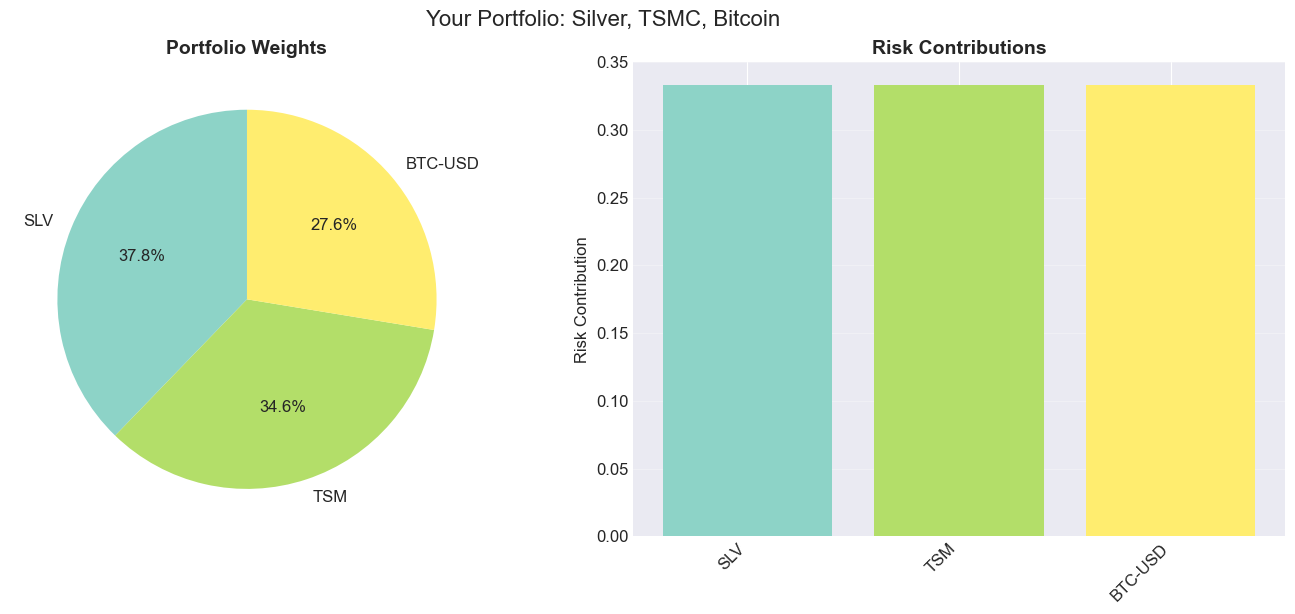


📈 Generating Cumulative Returns Chart...


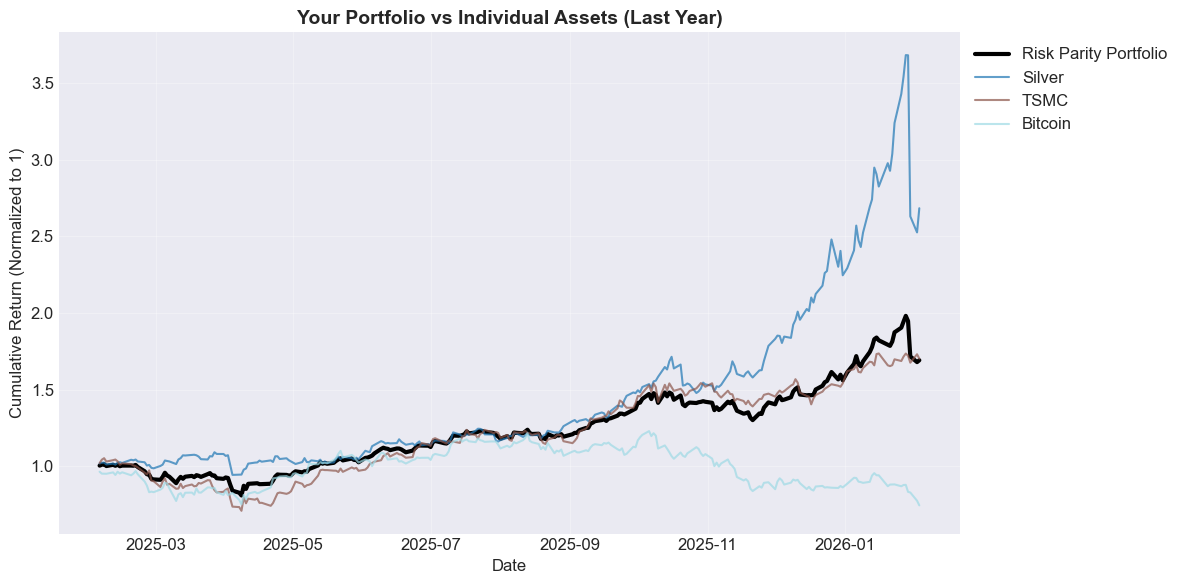


⚖️  Generating Risk Parity vs Equal Weight Comparison...


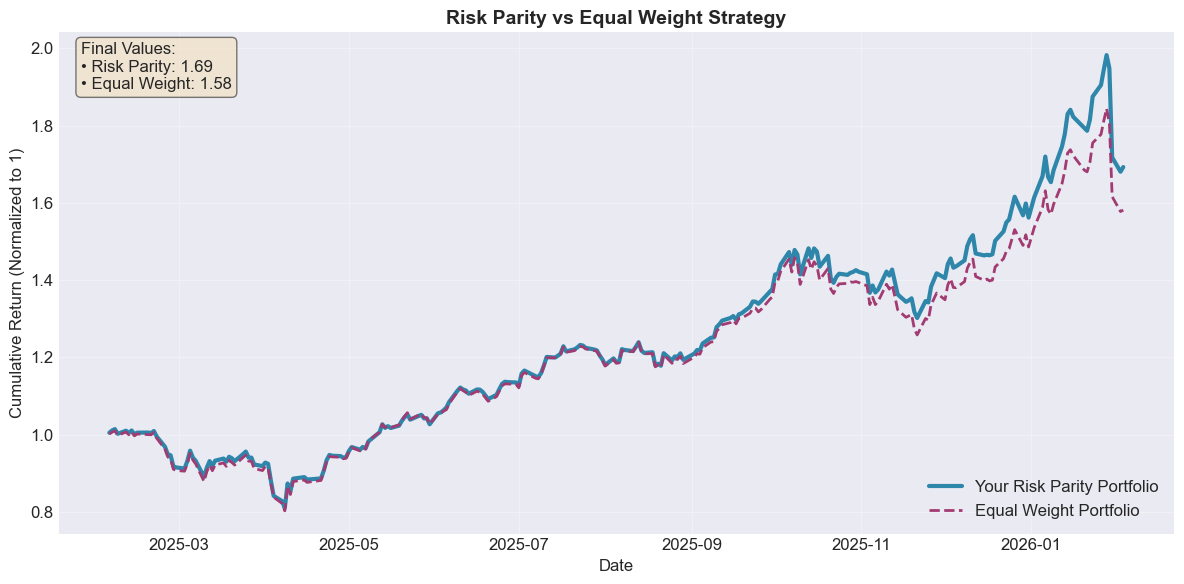


📉 Generating Correlation Matrix...


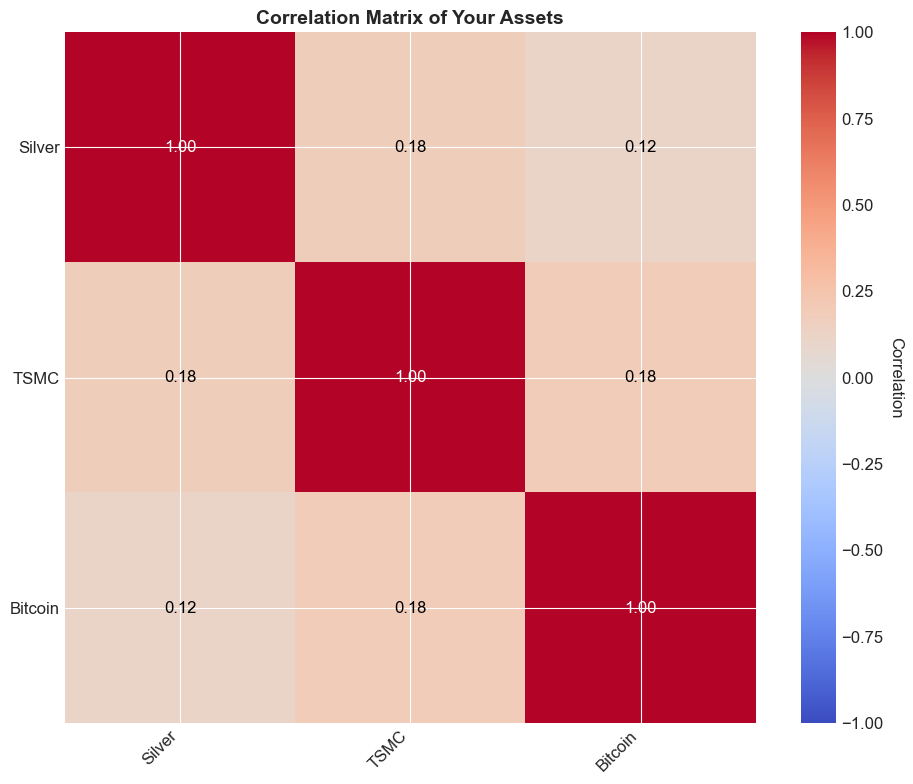

In [7]:
if success:
    print("\n" + "═"*70)
    print("📈 VISUALIZATIONS")
    print("═"*70)
    
    # Ask user which visualizations they want
    print("\nWhich visualizations would you like to see?")
    print("1. 📊 Portfolio Allocations (Weights & Risk Contributions)")
    print("2. 📈 Cumulative Returns (Your Portfolio vs Individual Assets)")
    print("3. ⚖️  Risk Parity vs Equal Weight Comparison")
    print("4. 📉 Correlation Matrix of Your Assets")
    print("5. 🎨 All of the above (Recommended)")
    
    while True:
        try:
            viz_choice = input("\nEnter choice (1-5, default=5): ").strip()
            if viz_choice == "":
                viz_choice = "5"
            viz_choice = int(viz_choice)
            if 1 <= viz_choice <= 5:
                break
            else:
                print("⚠️  Please enter 1, 2, 3, 4, or 5.")
        except ValueError:
            print("⚠️  Please enter a valid number.")
    
    # Create visualizations based on choice
    show_all = (viz_choice == 5)
    
    if viz_choice in [1, 5]:
        print("\n📊 Generating Portfolio Allocation Charts...")
        fig1 = portfolio.plot_allocations()
        plt.suptitle(f'Your Portfolio: {", ".join([next((n for n, t in assets_tickers.items() if t == ticker), ticker) for ticker in user_tickers])}', 
                     fontsize=16, y=1.02)
        plt.show()
    
    if viz_choice in [2, 5]:
        print("\n📈 Generating Cumulative Returns Chart...")
        fig2 = portfolio.plot_cumulative_returns(lookback_days=252)
        # Get display names for legend
        display_names = [next((n for n, t in assets_tickers.items() if t == ticker), ticker) for ticker in user_tickers]
        plt.title(f'Your Portfolio vs Individual Assets (Last Year)', fontsize=14, fontweight='bold')
        
        # Improve legend with asset names
        ax = plt.gca()
        handles, labels = ax.get_legend_handles_labels()
        # Replace tickers with names in legend
        for i, label in enumerate(labels):
            if label in assets_tickers.values():
                labels[i] = next((n for n, t in assets_tickers.items() if t == label), label)
        ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(1, 1))
        
        plt.tight_layout()
        plt.show()
    
    if viz_choice in [3, 5]:
        print("\n⚖️  Generating Risk Parity vs Equal Weight Comparison...")
        # Calculate both portfolios
        portfolio_cumulative, assets_cumulative = portfolio.calculate_cumulative_returns(252)
        
        equal_weights = np.ones(len(user_tickers)) / len(user_tickers)
        recent_returns = portfolio.data.iloc[-252:].pct_change().dropna()
        equal_returns = recent_returns.dot(equal_weights)
        equal_cumulative = (1 + equal_returns).cumprod()
        
        # Plot comparison
        fig3, ax = plt.subplots(figsize=(12, 6))
        ax.plot(portfolio_cumulative.index, portfolio_cumulative.values, 
                label='Your Risk Parity Portfolio', linewidth=3, color='#2E86AB')
        ax.plot(equal_cumulative.index, equal_cumulative.values, 
                label='Equal Weight Portfolio', linewidth=2, color='#A23B72', linestyle='--')
        
        ax.set_title('Risk Parity vs Equal Weight Strategy', fontsize=14, fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Cumulative Return (Normalized to 1)')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Add final values
        final_rp = portfolio_cumulative.iloc[-1]
        final_eq = equal_cumulative.iloc[-1]
        ax.text(0.02, 0.98, f'Final Values:\n• Risk Parity: {final_rp:.2f}\n• Equal Weight: {final_eq:.2f}', 
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        plt.show()
    
    if viz_choice in [4, 5]:
        print("\n📉 Generating Correlation Matrix...")
        # Correlation matrix
        correlation_matrix = portfolio.returns.corr()
        
        # Get display names for correlation matrix
        display_names_corr = [next((n for n, t in assets_tickers.items() if t == ticker), ticker) for ticker in portfolio.tickers]
        
        fig4, ax = plt.subplots(figsize=(10, 8))
        im = ax.imshow(correlation_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
        
        # Add labels with display names
        ax.set_xticks(np.arange(len(display_names_corr)))
        ax.set_yticks(np.arange(len(display_names_corr)))
        ax.set_xticklabels(display_names_corr, rotation=45, ha='right')
        ax.set_yticklabels(display_names_corr)
        
        # Add colorbar
        cbar = ax.figure.colorbar(im, ax=ax)
        cbar.ax.set_ylabel('Correlation', rotation=-90, va="bottom")
        
        # Add correlation values
        for i in range(len(display_names_corr)):
            for j in range(len(display_names_corr)):
                text = ax.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                              ha="center", va="center", color="black" if abs(correlation_matrix.iloc[i, j]) < 0.7 else "white")
        
        ax.set_title('Correlation Matrix of Your Assets', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

# Black-Scholes Pricing

In [8]:
print("╔══════════════════════════════════════════════════════════════════════╗")
print("║                BLACK-SCHOLES OPTIONS ANALYSIS                        ║")
print("╚══════════════════════════════════════════════════════════════════════╝")
print("\nThis part analyzes options using the Black-Scholes model")
print("and compares theoretical prices with market prices.")
print("\n" + "═"*70)

╔══════════════════════════════════════════════════════════════════════╗
║                BLACK-SCHOLES OPTIONS ANALYSIS                        ║
╚══════════════════════════════════════════════════════════════════════╝

This part analyzes options using the Black-Scholes model
and compares theoretical prices with market prices.

══════════════════════════════════════════════════════════════════════


In [9]:
print("📁 LOAD PORTFOLIO OR SELECT ASSET")
print("═"*70)

print("\nChoose an option:")
print("1. 📂 Load the most allocated asset from your Risk Parity Portfolio")
print("2. 🎯 Enter a different single asset ticker for options analysis")

while True:
    choice = input("\nEnter choice (1 or 2): \n\t1. 📂 Load the most allocated asset from your Risk Parity Portfolio or \n\t2. 🎯 Enter a different single asset ticker for options analysis").strip()
    if choice in ['1', '2']:
        break
    print("Please enter 1 or 2.")

if choice == '1':
    target_ticker = top_asset_ticker
    target_name = top_asset_name
    print(f"\n✅ Using your top asset: {top_asset_name} ({top_asset_ticker})")
    print(f"   Portfolio weight: {top_weight:.2%}")
    print(f"   Current price: ${portfolio.data.iloc[-1, idx]:.2f}")
else:
    target_ticker = input("\nEnter ticker for options analysis: ").strip().upper()
    target_name = next((n for n, t in assets_tickers.items() if t == target_ticker), target_ticker)
    print(f"\n✅ Will analyze options for: {target_name} ({target_ticker})")

print(f"\n" + "="*70)
print(f"TARGET ASSET: {target_name} ({target_ticker})")
print("="*70)

📁 LOAD PORTFOLIO OR SELECT ASSET
══════════════════════════════════════════════════════════════════════

Choose an option:
1. 📂 Load the most allocated asset from your Risk Parity Portfolio
2. 🎯 Enter a different single asset ticker for options analysis

✅ Using your top asset: Silver (SLV)
   Portfolio weight: 37.76%
   Current price: $76.96

TARGET ASSET: Silver (SLV)


In [10]:
print(f"\n🔧 Setting up Black-Scholes pricer for {target_ticker}...")
print("="*70)

# Initialize the pricer
pricer = BlackScholesPricer(ticker=target_ticker)

print(f"\n✅ Option pricer initialized")
print(f"   Current price: ${pricer.current_price:.2f}")
print(f"   Risk-free rate: {pricer.risk_free_rate:.1%}")

# Calculate historical volatility
print("\n📊 Calculating historical volatility...")
historical_vol = pricer.calculate_historical_volatility()
print(f"   Historical volatility: {historical_vol:.2%}")


🔧 Setting up Black-Scholes pricer for SLV...
Current price of SLV: $79.18

✅ Option pricer initialized
   Current price: $79.18
   Risk-free rate: 3.0%

📊 Calculating historical volatility...
Historical volatility (252 days): 47.39%
   Historical volatility: 47.39%


In [11]:
print("\nFetching available option expiration dates...")
print("="*70)

try:
    # Get available expirations
    stock = yf.Ticker(target_ticker)
    expirations = stock.options
    
    if not expirations:
        raise ValueError(f"No option data available for {target_ticker}")
    
    print(f"\n📅 Available expiration dates for {target_ticker}:")
    for i, exp in enumerate(expirations[:10]):  # Show first 10
        # Calculate days to expiry
        exp_date = pd.to_datetime(exp)
        days_to_expiry = (exp_date - pd.Timestamp.now()).days
        print(f"  {i+1:2}. {exp} (in {days_to_expiry} days)")
    
    if len(expirations) > 10:
        print(f"  ... and {len(expirations)-10} more")
    
    # Let user choose expiration
    print("\nChoose expiration date:")
    print("   Enter number (1, 2, 3, etc.)")
    print("   Or enter 'nearest' for the nearest expiration")
    print("   Or enter a specific date (YYYY-MM-DD)")
    
    exp_choice = input("\nYour choice: ").strip()
    
    if exp_choice.lower() == 'nearest' or exp_choice == '':
        expiration_date = expirations[0]
    elif exp_choice.isdigit():
        idx = int(exp_choice) - 1
        if 0 <= idx < len(expirations):
            expiration_date = expirations[idx]
        else:
            print(f"Invalid number, using nearest expiration")
            expiration_date = expirations[0]
    else:
        # Assume user entered a date
        expiration_date = exp_choice
    
    print(f"\n⏳ Fetching option chain for expiration: {expiration_date}...")
    
    # Fetch the option chain
    option_chain = pricer.fetch_option_chain(expiration_date=expiration_date)
    
    if option_chain is not None:
        print(f"\n✅ Option chain loaded successfully")
        print(f"   Total options: {len(option_chain)}")
        print(f"   Calls: {len(option_chain[option_chain['type'] == 'call'])}")
        print(f"   Puts: {len(option_chain[option_chain['type'] == 'put'])}")
        
        # Show some sample data
        print("\n📋 Sample of option chain:")
        print(option_chain[['strike', 'type', 'bid', 'ask', 'impliedVolatility']].head().to_string())
        
except Exception as e:
    print(f"\n❌ Error: {e}")
    print("\n   Possible reasons:")
    print("   1. Asset may not have options available")
    print("   2. Internet connection issue")
    print("   3. Yahoo Finance API limitation")
    raise SystemExit("Could not fetch option chain")


Fetching available option expiration dates...



📅 Available expiration dates for SLV:
   1. 2026-02-06 (in 0 days)
   2. 2026-02-09 (in 3 days)
   3. 2026-02-11 (in 5 days)
   4. 2026-02-13 (in 7 days)
   5. 2026-02-17 (in 11 days)
   6. 2026-02-20 (in 14 days)
   7. 2026-02-21 (in 15 days)
   8. 2026-02-23 (in 17 days)
   9. 2026-02-27 (in 21 days)
  10. 2026-03-06 (in 28 days)
  ... and 15 more

Choose expiration date:
   Enter number (1, 2, 3, etc.)
   Or enter 'nearest' for the nearest expiration
   Or enter a specific date (YYYY-MM-DD)

⏳ Fetching option chain for expiration: 2026-02-27...
Fetching option chain for SLV with expiration 2026-02-27...
✅ Successfully fetched 283 options

✅ Option chain loaded successfully
   Total options: 283
   Calls: 147
   Puts: 136

📋 Sample of option chain:
   strike  type    bid    ask  impliedVolatility
0    20.0  call  59.15  60.70           3.427736
1    25.0  call  54.20  54.50           2.218754
2    30.0  call  49.20  50.75           2.512699
3    35.0  call  44.25  45.80           2.

In [12]:
print("\n⚖️  Calculating Black-Scholes prices for all options...")
print(f"   Using historical volatility: {historical_vol:.2%}")
print("="*70)

# Calculate Black-Scholes prices
chain_with_bs = pricer.calculate_black_scholes_prices(volatility=historical_vol)

print("\n✅ Black-Scholes prices calculated")
print(f"   Options processed: {len(chain_with_bs)}")

# Show comparison summary
print("\n📊 PRICE COMPARISON SUMMARY:")
print("-"*40)

# Calculate basic statistics
market_mean = chain_with_bs['market_price'].mean()
bs_mean = chain_with_bs['bs_price'].mean()
avg_diff = chain_with_bs['price_difference'].mean()
avg_abs_diff = chain_with_bs['price_difference'].abs().mean()
avg_pct_error = chain_with_bs['price_error_pct'].abs().mean()

print(f"Average Market Price: ${market_mean:.2f}")
print(f"Average BS Price:     ${bs_mean:.2f}")
print(f"Average Difference:   ${avg_diff:.3f}")
print(f"Average Abs Diff:     ${avg_abs_diff:.3f}")
print(f"Average % Error:      {avg_pct_error:.1f}%")

# Show best and worst matches
best_match = chain_with_bs.loc[chain_with_bs['price_difference'].abs().idxmin()]
worst_match = chain_with_bs.loc[chain_with_bs['price_difference'].abs().idxmax()]

print(f"\n🏆 BEST MATCH (closest to market):")
print(f"   {best_match['type'].upper()} option at ${best_match['strike']:.0f}")
print(f"   Market: ${best_match['market_price']:.2f}, BS: ${best_match['bs_price']:.2f}")
print(f"   Difference: ${best_match['price_difference']:.3f}")

print(f"\n⚠️  WORST MATCH (furthest from market):")
print(f"   {worst_match['type'].upper()} option at ${worst_match['strike']:.0f}")
print(f"   Market: ${worst_match['market_price']:.2f}, BS: ${worst_match['bs_price']:.2f}")
print(f"   Difference: ${worst_match['price_difference']:.3f}")


⚖️  Calculating Black-Scholes prices for all options...
   Using historical volatility: 47.39%

✅ Black-Scholes prices calculated
   Options processed: 283

📊 PRICE COMPARISON SUMMARY:
----------------------------------------
Average Market Price: $13.89
Average BS Price:     $12.03
Average Difference:   $1.854
Average Abs Diff:     $1.854
Average % Error:      49.5%

🏆 BEST MATCH (closest to market):
   PUT option at $25
   Market: $0.02, BS: $0.00
   Difference: $0.020

⚠️  WORST MATCH (furthest from market):
   CALL option at $82
   Market: $6.40, BS: $3.17
   Difference: $3.225



📈 Generating visualizations...

1. 📊 Generating Price Comparison Plots...


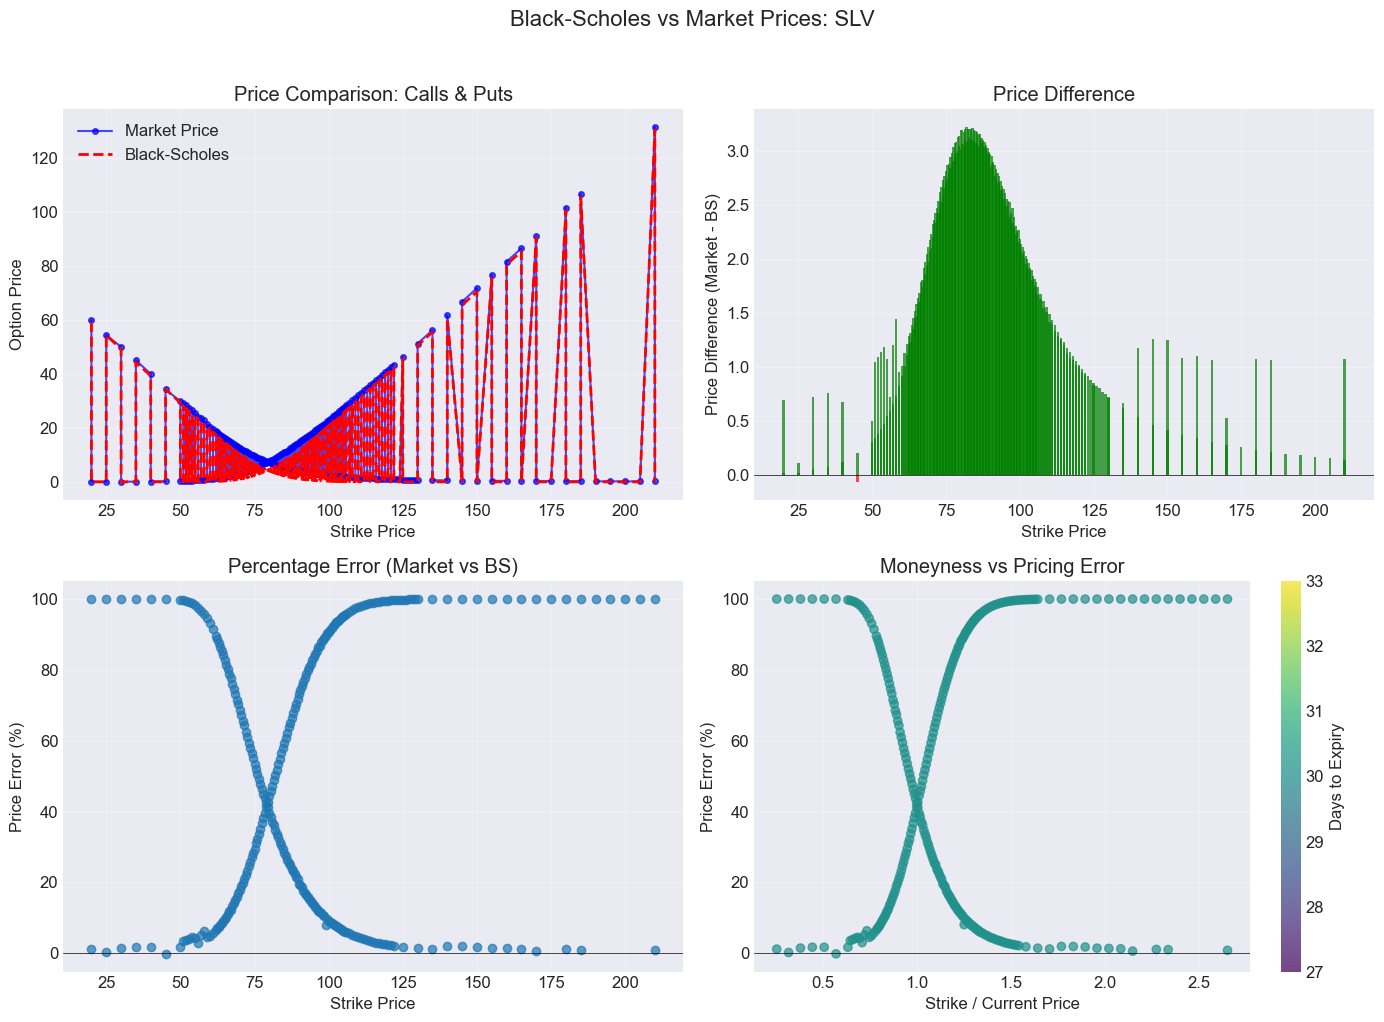


2. 📈 Generating Volatility Smile Plot...


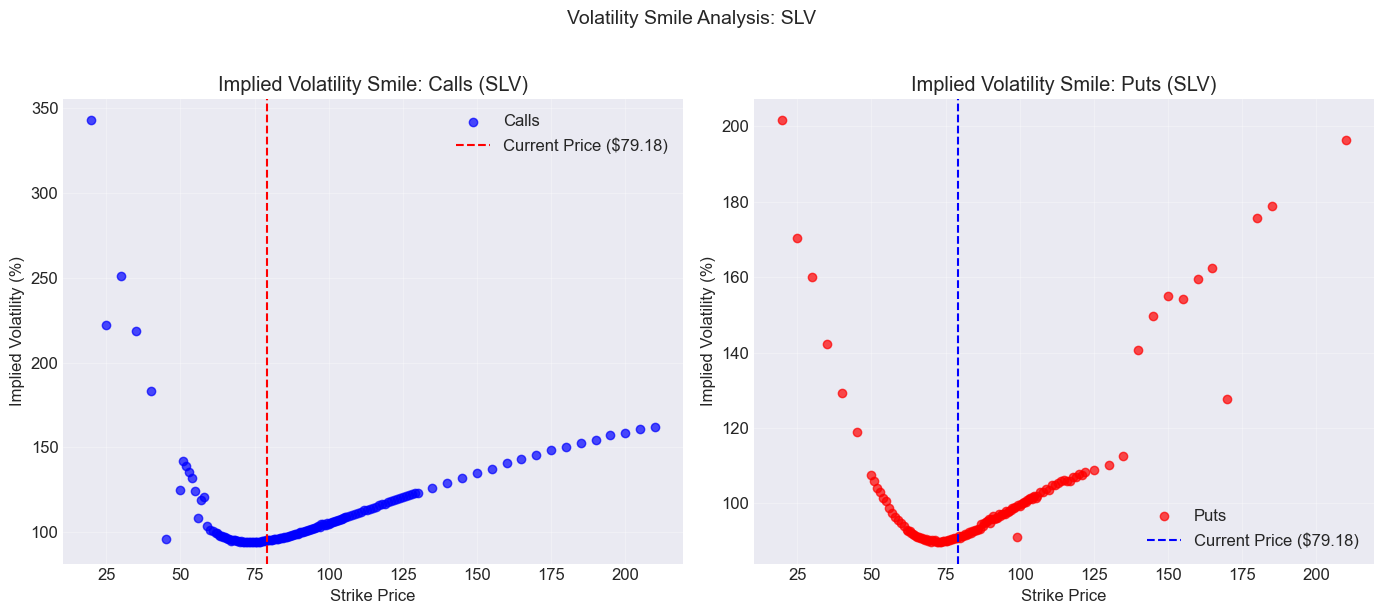


3. 📐 Generating Greeks Analysis...


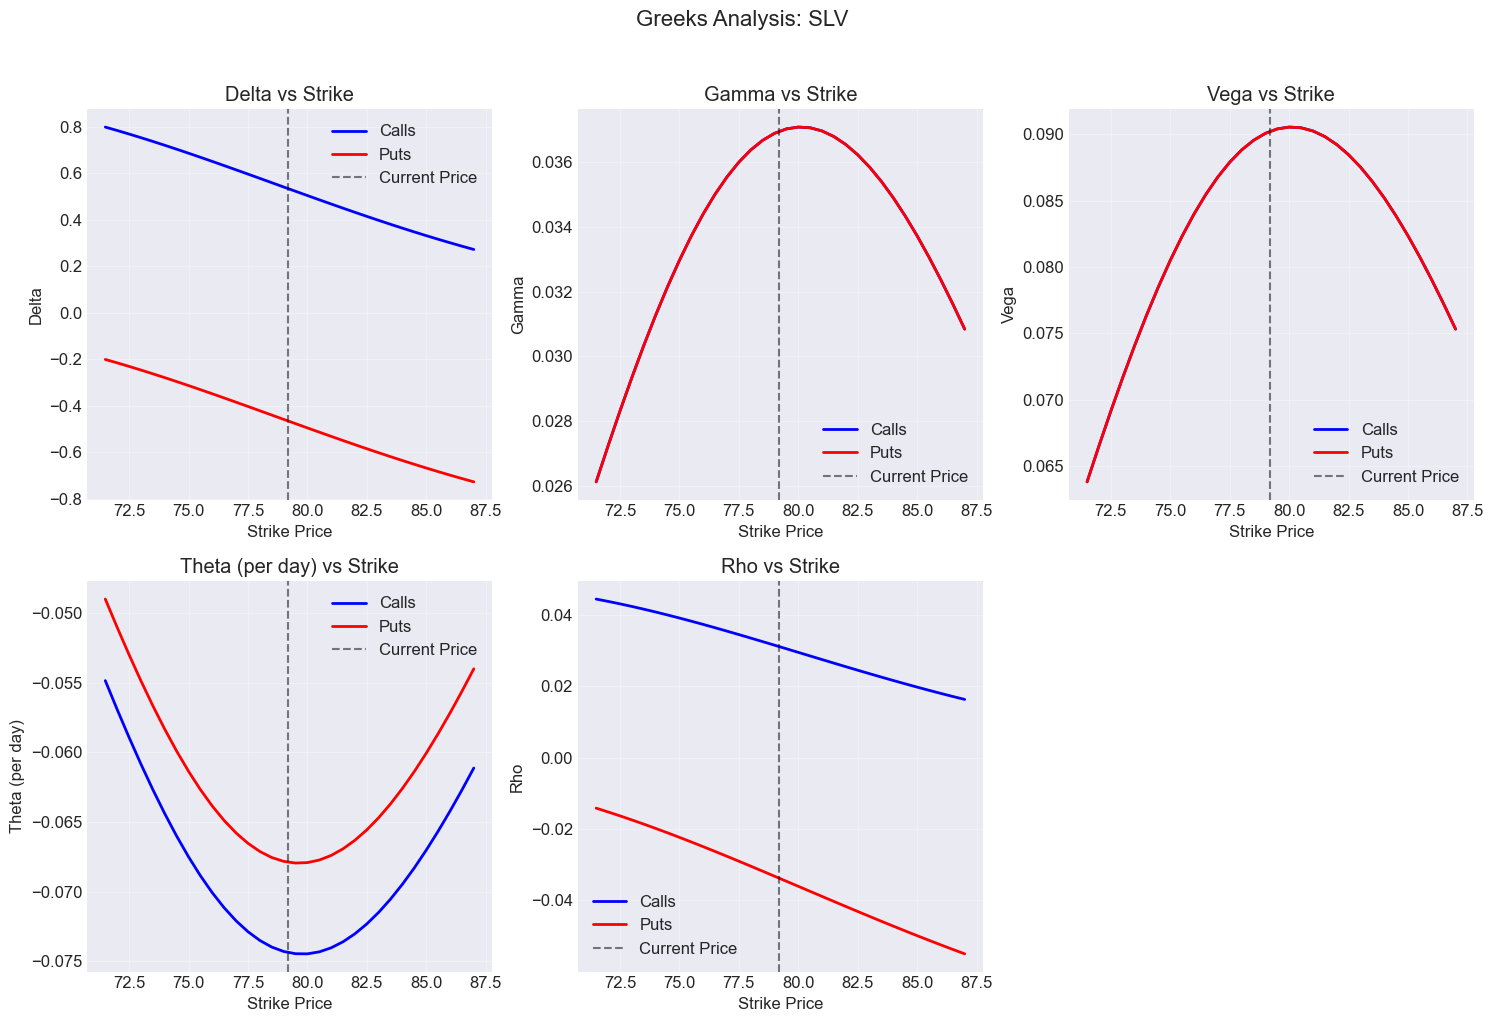


✅ All visualizations complete!


In [13]:
print("\n📈 Generating visualizations...")
print("="*70)

# Visualization 1: Price Comparison
print("\n1. 📊 Generating Price Comparison Plots...")
fig1 = pricer.plot_comparison(chain_with_bs, option_type='all')
plt.show()

# Visualization 2: Volatility Smile
print("\n2. 📈 Generating Volatility Smile Plot...")
fig2 = pricer.plot_volatility_smile(chain_with_bs)
plt.show()

# Visualization 3: Greeks Analysis
print("\n3. 📐 Generating Greeks Analysis...")
fig3 = pricer.plot_greeks_analysis(chain_with_bs)
plt.show()

print("\n✅ All visualizations complete!")

In [14]:
print("\n🔍 Running detailed analysis...")
print("="*70)

# Analyze by option type
for opt_type in ['call', 'put']:
    type_data = chain_with_bs[chain_with_bs['type'] == opt_type]
    
    if not type_data.empty:
        print(f"\n📊 {opt_type.upper()} OPTIONS ANALYSIS:")
        print("-"*40)
        
        # ITM, ATM, OTM classification
        itm_threshold = 0.95 if opt_type == 'call' else 1.05
        otm_threshold = 1.05 if opt_type == 'call' else 0.95
        
        itm = type_data[type_data['strike'] / pricer.current_price <= itm_threshold]
        atm = type_data[(type_data['strike'] / pricer.current_price > itm_threshold) & 
                       (type_data['strike'] / pricer.current_price < otm_threshold)]
        otm = type_data[type_data['strike'] / pricer.current_price >= otm_threshold]
        
        print(f"   In-the-Money (ITM):     {len(itm)} options")
        print(f"   At-the-Money (ATM):     {len(atm)} options")
        print(f"   Out-of-the-Money (OTM): {len(otm)} options")
        
        if len(itm) > 0:
            print(f"   ITM avg error:          {itm['price_error_pct'].abs().mean():.1f}%")
        if len(atm) > 0:
            print(f"   ATM avg error:          {atm['price_error_pct'].abs().mean():.1f}%")
        if len(otm) > 0:
            print(f"   OTM avg error:          {otm['price_error_pct'].abs().mean():.1f}%")

# Show top 5 most overpriced and underpriced options
print("\n💰 TOP 5 MOST OVERPRICED (Market > BS):")
overpriced = chain_with_bs[chain_with_bs['price_difference'] > 0].nlargest(5, 'price_difference')
print(overpriced[['type', 'strike', 'market_price', 'bs_price', 'price_difference']].to_string(index=False))

print("\n📉 TOP 5 MOST UNDERPRICED (Market < BS):")
underpriced = chain_with_bs[chain_with_bs['price_difference'] < 0].nsmallest(5, 'price_difference')
print(underpriced[['type', 'strike', 'market_price', 'bs_price', 'price_difference']].to_string(index=False))


🔍 Running detailed analysis...

📊 CALL OPTIONS ANALYSIS:
----------------------------------------
   In-the-Money (ITM):     45 options
   At-the-Money (ATM):     16 options
   Out-of-the-Money (OTM): 86 options
   ITM avg error:          11.0%
   ATM avg error:          42.0%
   OTM avg error:          89.2%

📊 PUT OPTIONS ANALYSIS:
----------------------------------------
   In-the-Money (ITM):     61 options
   At-the-Money (ATM):     0 options
   Out-of-the-Money (OTM): 91 options
   ITM avg error:          72.0%
   OTM avg error:          16.0%

💰 TOP 5 MOST OVERPRICED (Market > BS):
type  strike  market_price  bs_price  price_difference
call    82.0         6.400  3.174678          3.225322
call    84.0         5.700  2.484179          3.215821
call    83.0         6.025  2.813125          3.211875
call    82.5         6.200  2.989731          3.210269
call    81.5         6.575  3.368142          3.206858

📉 TOP 5 MOST UNDERPRICED (Market < BS):
type  strike  market_price  bs_p


📈 Analyzing sensitivity to volatility...

Testing volatility levels: 23.7%, 35.5%, 47.4%, 59.2%, 71.1%

🔍 Sample ATM Call Option:
   Strike: $75.50
   Current price: $79.18
   Market price: $9.28
   BS price (at 47.4% vol): $6.40

📊 Price at different volatility levels:
----------------------------------------
   23.7% vol: $4.57 (Error: $-4.71)
   35.5% vol: $5.44 (Error: $-3.83)
   47.4% vol: $6.40 (Error: $-2.88)
   59.2% vol: $7.39 (Error: $-1.89)
   71.1% vol: $8.39 (Error: $-0.88)


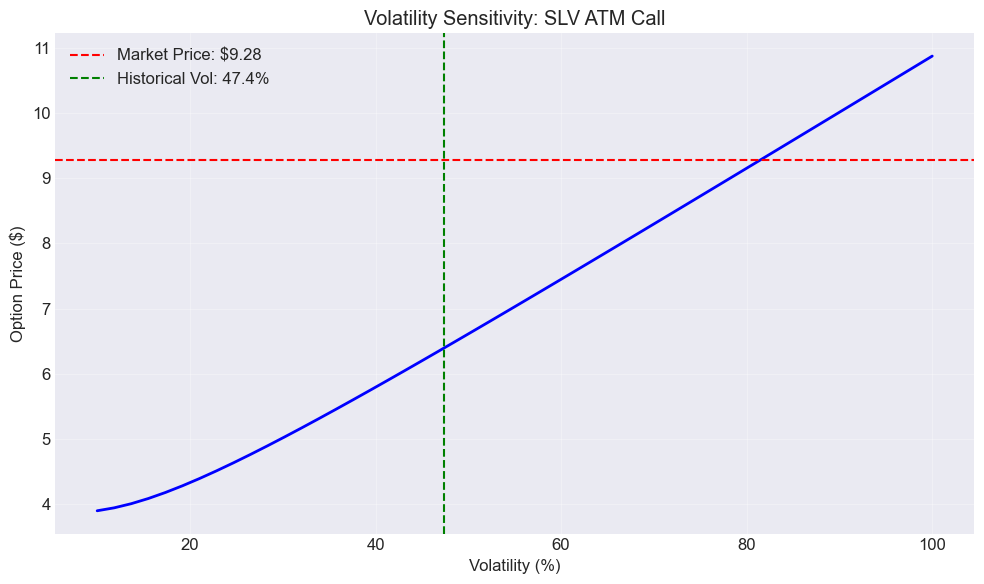

In [15]:
print("\n📈 Analyzing sensitivity to volatility...")
print("="*70)

# Test different volatility levels
vol_levels = [historical_vol * 0.5, historical_vol * 0.75, historical_vol, 
              historical_vol * 1.25, historical_vol * 1.5]

print(f"\nTesting volatility levels: {', '.join([f'{v:.1%}' for v in vol_levels])}")

# Pick a representative option (ATM call)
atm_options = chain_with_bs[
    (abs(chain_with_bs['strike'] / pricer.current_price - 1) < 0.05) & 
    (chain_with_bs['type'] == 'call')
]

if not atm_options.empty:
    sample_option = atm_options.iloc[0]
    
    print(f"\n🔍 Sample ATM Call Option:")
    print(f"   Strike: ${sample_option['strike']:.2f}")
    print(f"   Current price: ${pricer.current_price:.2f}")
    print(f"   Market price: ${sample_option['market_price']:.2f}")
    print(f"   BS price (at {historical_vol:.1%} vol): ${sample_option['bs_price']:.2f}")
    
    print(f"\n📊 Price at different volatility levels:")
    print("-"*40)
    
    for vol in vol_levels:
        bs_price = pricer.black_scholes(
            S=pricer.current_price,
            K=sample_option['strike'],
            T=sample_option['time_to_expiry'],
            r=pricer.risk_free_rate,
            sigma=vol,
            option_type='call'
        )
        print(f"   {vol:.1%} vol: ${bs_price:.2f} (Error: ${bs_price - sample_option['market_price']:.2f})")
    
    # Plot volatility sensitivity
    fig, ax = plt.subplots(figsize=(10, 6))
    
    vol_range = np.linspace(0.1, 1.0, 50)  # 10% to 100% volatility
    bs_prices = []
    
    for vol in vol_range:
        price = pricer.black_scholes(
            S=pricer.current_price,
            K=sample_option['strike'],
            T=sample_option['time_to_expiry'],
            r=pricer.risk_free_rate,
            sigma=vol,
            option_type='call'
        )
        bs_prices.append(price)
    
    ax.plot(vol_range * 100, bs_prices, 'b-', linewidth=2)
    ax.axhline(y=sample_option['market_price'], color='r', linestyle='--', 
               label=f'Market Price: ${sample_option["market_price"]:.2f}')
    ax.axvline(x=historical_vol * 100, color='g', linestyle='--', 
               label=f'Historical Vol: {historical_vol:.1%}')
    
    ax.set_xlabel('Volatility (%)')
    ax.set_ylabel('Option Price ($)')
    ax.set_title(f'Volatility Sensitivity: {target_ticker} ATM Call')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️  No ATM call options found for sensitivity analysis")

In [16]:
print(f"\n🎯 OPTIONS ANALYSIS SUMMARY FOR {target_ticker}")
print("-"*70)

print(f"\n📈 MODEL PERFORMANCE:")
print(f"   • Average pricing error: {avg_pct_error:.1f}%")
print(f"   • Average absolute difference: ${avg_abs_diff:.3f}")
print(f"   • Best match error: ${best_match['price_difference']:.3f}")
print(f"   • Worst match error: ${worst_match['price_difference']:.3f}")

print(f"\n📊 MARKET CHARACTERISTICS:")
print(f"   • Current price: ${pricer.current_price:.2f}")
print(f"   • Options available: {len(chain_with_bs)}")
calls = len(chain_with_bs[chain_with_bs['type'] == 'call'])
puts = len(chain_with_bs[chain_with_bs['type'] == 'put'])
print(f"   • Calls/Puts ratio: {calls}/{puts}")

print(f"\n🎯 MODEL PARAMETERS:")
print(f"   • Risk-free rate: {pricer.risk_free_rate:.1%}")
print(f"   • Historical volatility: {historical_vol:.1%}")

print(f"\n💡 KEY INSIGHTS:")
print(f"   1. Black-Scholes tends to work best for ATM options")
print(f"   2. Extreme OTM/ITM options often show larger pricing errors")
print(f"   3. Differences may indicate market sentiment or arbitrage opportunities")
print(f"   4. Volatility assumption significantly impacts option pricing")

print(f"\n🔍 RECOMMENDATIONS:")
print(f"   1. Use Black-Scholes as a baseline, not an absolute predictor")
print(f"   2. Monitor implied volatility for better market insights")
print(f"   3. Consider transaction costs before any arbitrage attempts")
print(f"   4. Adjust volatility assumption based on market conditions")

print(f"\n" + "="*70)
print("🎉 OPTIONS ANALYSIS COMPLETE!")
print("="*70)
print(f"\nThank you for using the Black-Scholes Options Analyzer!")
print(f"Asset analyzed: {target_name} ({target_ticker})")
print(f"Portfolio top asset was: {top_asset_name} ({top_asset_ticker})")


🎯 OPTIONS ANALYSIS SUMMARY FOR SLV
----------------------------------------------------------------------

📈 MODEL PERFORMANCE:
   • Average pricing error: 49.5%
   • Average absolute difference: $1.854
   • Best match error: $0.020
   • Worst match error: $3.225

📊 MARKET CHARACTERISTICS:
   • Current price: $79.18
   • Options available: 283
   • Calls/Puts ratio: 147/136

🎯 MODEL PARAMETERS:
   • Risk-free rate: 3.0%
   • Historical volatility: 47.4%

💡 KEY INSIGHTS:
   1. Black-Scholes tends to work best for ATM options
   2. Extreme OTM/ITM options often show larger pricing errors
   3. Differences may indicate market sentiment or arbitrage opportunities
   4. Volatility assumption significantly impacts option pricing

🔍 RECOMMENDATIONS:
   1. Use Black-Scholes as a baseline, not an absolute predictor
   2. Monitor implied volatility for better market insights
   3. Consider transaction costs before any arbitrage attempts
   4. Adjust volatility assumption based on market conditi